# Project Foundations for Data Science: FoodHub Data Analysis


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Assignment/foodhub_order.csv')

#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data?

In [ ]:
# Write your code here
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
df.shape

(1898, 9)

#### Observations:
There are 9 columns and 1898 row (Range Index) in the dataset.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The df.info() output in cell shows the data types for each column. Here's what those data types mean:

int64: This indicates integer data. Columns like order_id, customer_id, food_preparation_time, and delivery_time are stored as integers because they represent whole numbers.

float64: This indicates floating-point numbers, which are numbers with decimal points. The cost_of_the_order column is a float64 because order costs can have decimal values.

object: columns like restaurant_name, cuisine_type, day_of_the_week, and rating are object type, which means they contain text data.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
# Write your code here
missing_values = df.isnull().sum()
print(missing_values)

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


#### Observations:
No, There are no Misssing Values in the dataset


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed?

In [ ]:
# Write your code here
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [ ]:
# Write your code here
df['food_preparation_time'].describe()

,food_preparation_time
count,1898.000000
mean,27.371970
std,4.632481
min,20.000000
25%,23.000000
50%,27.000000
75%,31.000000
max,35.000000


#### Observations:
     The Minimum time for food preperation: 20min
     The Average time for food prepration:27.37min
     The Maximum time for food Prepration: 35min
     

### **Question 5:** How many orders are not rated?

In [ ]:
# Write the code here,How many orders are not rated?
# The code below counts the number of orders where the rating is 'Not given'.
unrated_orders = df[df['rating'] == 'Not given'].shape[0]
print(f"Number of orders not rated: {unrated_orders}")

Number of orders not rated: 736


#### Observations:
The Number of order which does not have any rating are 736

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration)

/tmp/ipython-input-450793877.py:16: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-450793877.py:16: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


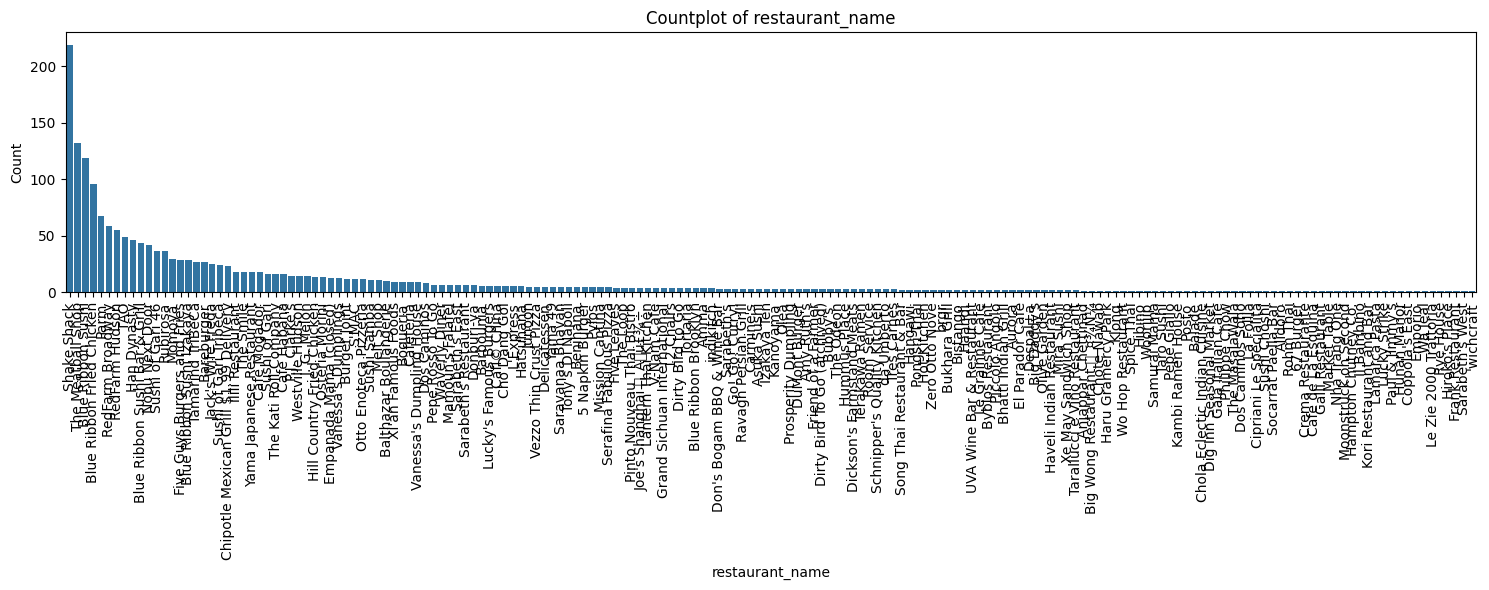

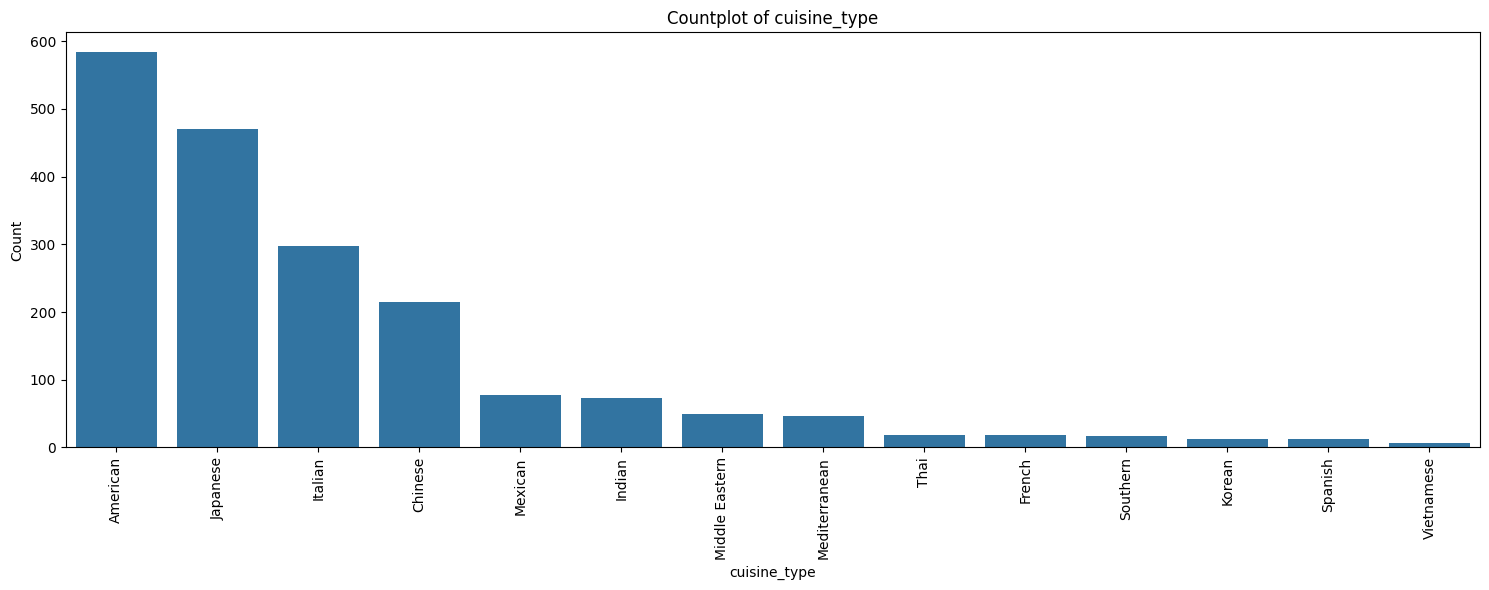

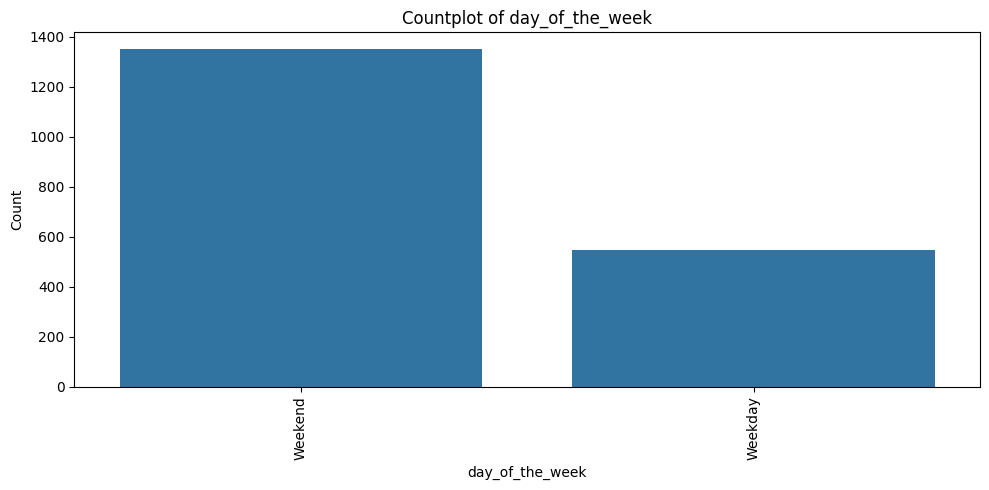

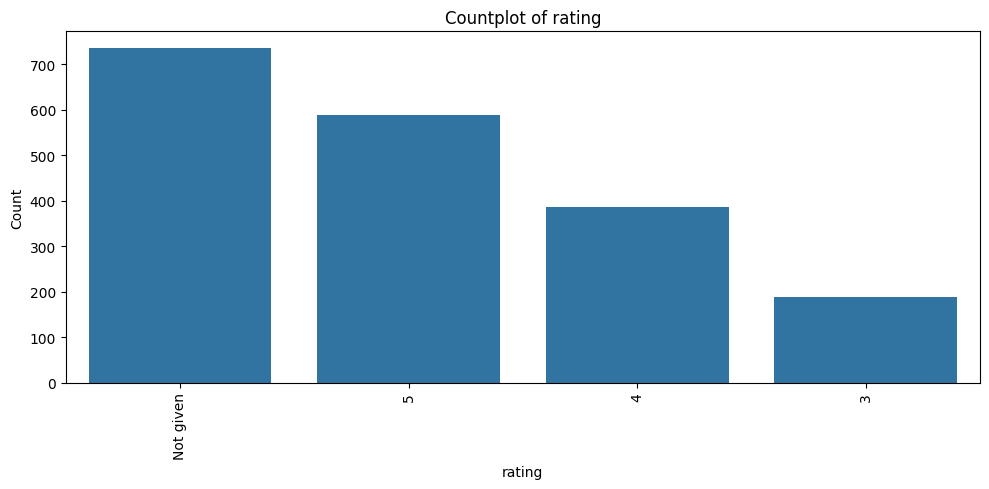

In [ ]:
# Explore categorical variables with countplots
categorical_columns = ['restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating']

for column in categorical_columns:
    # Increase figure size for columns with many unique values
    if column in ['restaurant_name', 'cuisine_type']:
        plt.figure(figsize=(15, 6))
    else:
        plt.figure(figsize=(10, 5))

    sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.title(f'Countplot of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

#Observation:
Restaurant Name: The countplot for restaurant_name shows a highly uneven distribution. A few restaurants, such as "Shake Shack" and "The Meatball Shop," have a significantly higher number of orders compared to the rest. This indicates that a small number of restaurants are driving a large portion of the business.
Cuisine Type: The cuisine_type countplot reveals that "American" and "Japanese" cuisines are the most popular among customers, followed by "Italian" and "Chinese." There is a considerable drop-off in order counts for other cuisine types.
Day of the Week: The day_of_the_week countplot clearly shows that there are more orders placed on "Weekend" days compared to "Weekday" days. This suggests that online food delivery is more popular on weekends.
Rating: The rating countplot highlights that a large number of orders have "Not given" ratings. Among the rated orders, ratings of 5 and 4 are the most frequent, while ratings of 1, 2, and 3 are less common. This indicates that customers who do provide ratings tend to give higher ratings, but a significant portion of customers do not provide any rating at all.


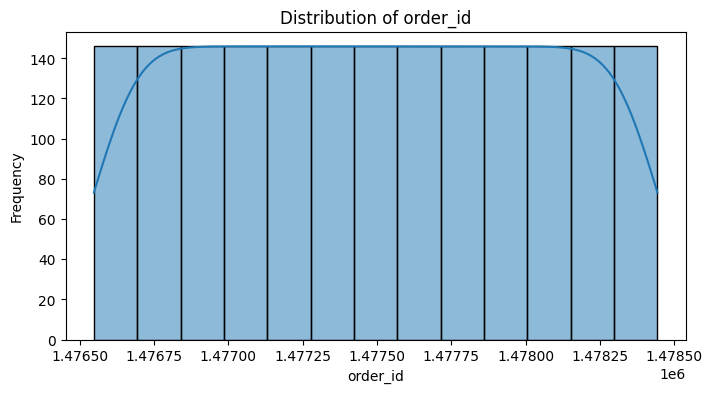

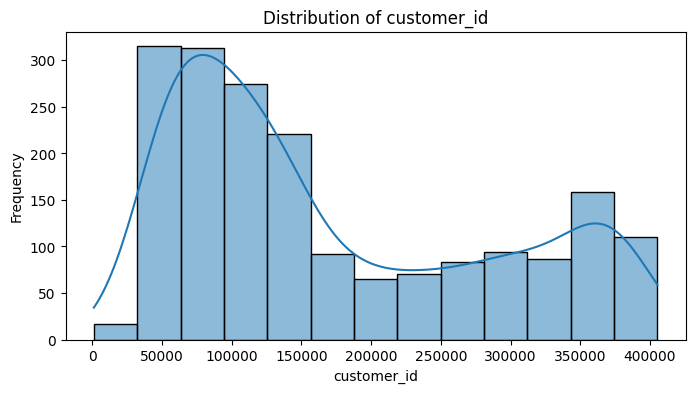

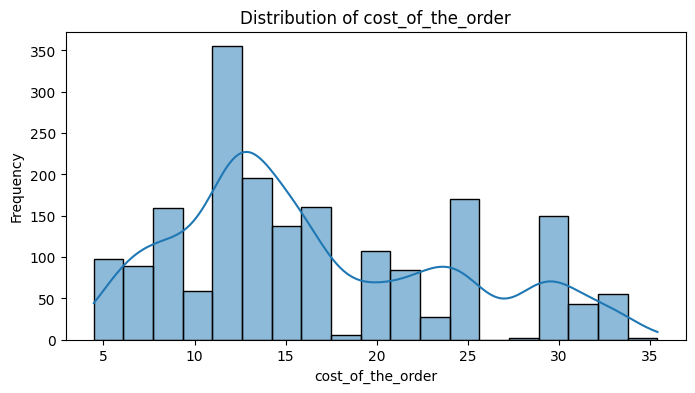

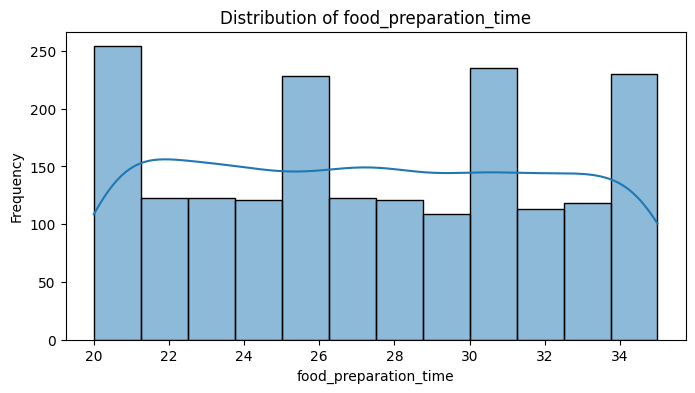

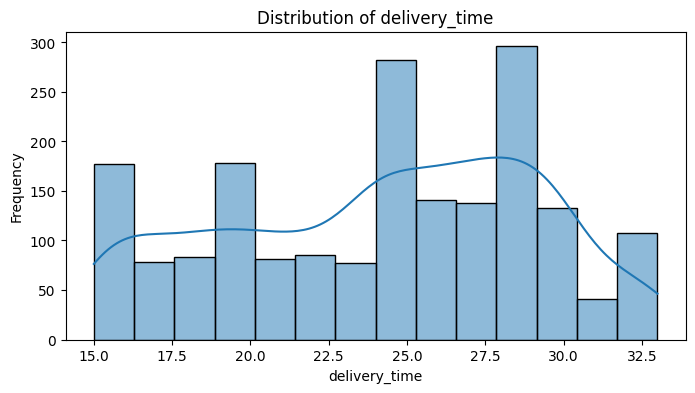

In [ ]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show() # Add plt.show() to display each plot

### Obeservation
order_id and customer_id: These columns represent unique identifiers and their distributions are not particularly meaningful in terms of typical numerical analysis. They appear to be spread relatively evenly, as expected for IDs.
cost_of_the_order: The distribution of the cost of the order appears to be right-skewed, meaning there are more orders with lower costs and fewer orders with higher costs. There might be a few outliers with very high costs.
food_preparation_time: The distribution of food preparation time seems to be somewhat uniform or slightly skewed. The times are concentrated within a specific range, which is expected as there would likely be minimum and maximum times for food preparation.
delivery_time: The distribution of delivery time appears to be somewhat normally distributed, or possibly slightly skewed. Like food preparation time, the delivery times are concentrated within a certain range, reflecting the typical time it takes for deliveries

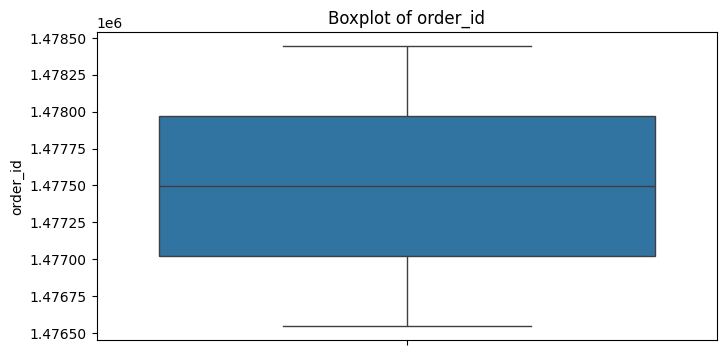

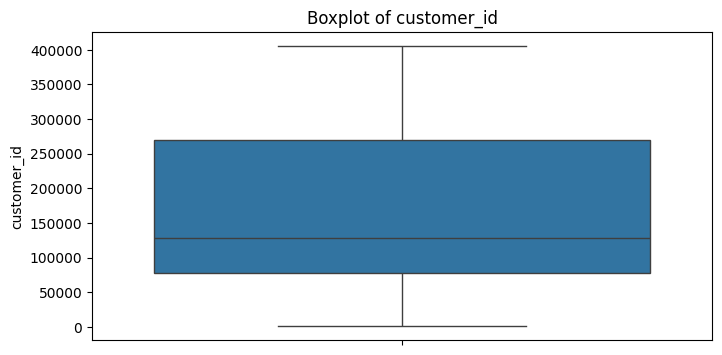

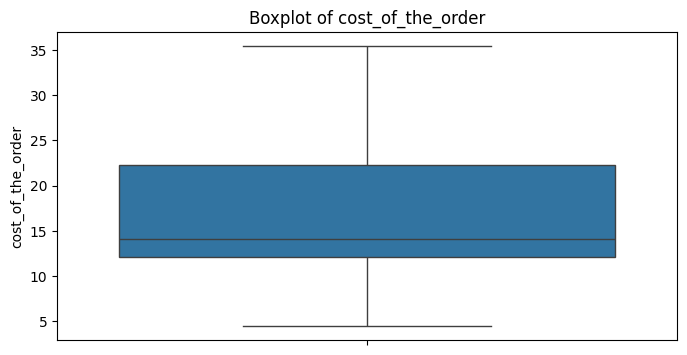

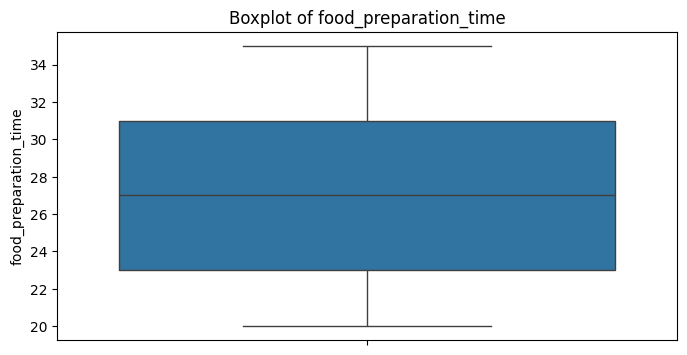

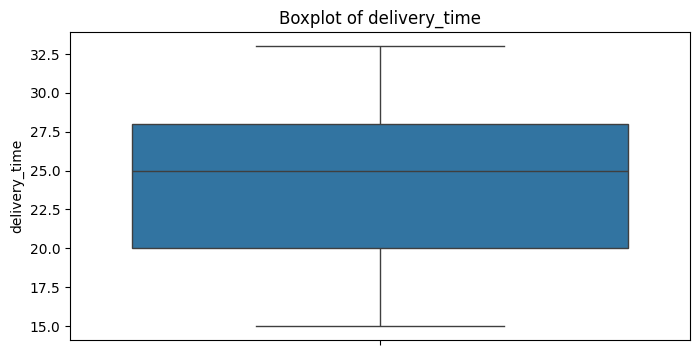

In [ ]:
# Create boxplots
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    plt.show()

#Observations
order_id and customer_id: As expected, the boxplots for these columns representing unique identifiers don't show a typical distribution like other numerical variables. They appear as single lines, which is normal for ID columns.
cost_of_the_order: The boxplot for the cost of the order shows the median around $14-15. The box indicates that the middle 50% of orders fall within a certain range. There are several points above the upper whisker, suggesting the presence of outliers with higher order costs.
food_preparation_time: The boxplot for food preparation time shows a relatively compact distribution, with the median around 27 minutes. The box and whiskers are relatively short, indicating less variability compared to the cost of the order. There don't appear to be significant outliers.
delivery_time: The boxplot for delivery time shows the median around 24-25 minutes. The distribution appears somewhat symmetrical, with the box and whiskers covering a reasonable range of delivery times. There are no apparent outliers in the delivery time.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

In [ ]:
# Write the code here
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The top 5 Restaurant are:
Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, Parm with the order count of 219,132,119,96, and 68 respectively.

### **Question 8**: Which is the most popular cuisine on weekends?

In [ ]:
# Write the code here
df.groupby('day_of_the_week')['cuisine_type'].value_counts()

day_of_the_week  cuisine_type  
Weekday          American          169
                 Japanese          135
                 Italian            91
                 Chinese            52
                 Indian             24
                 Mexican            24
                 Middle Eastern     17
                 Mediterranean      14
                 Southern            6
                 French              5
                 Thai                4
                 Vietnamese          3
                 Korean              2
                 Spanish             1
Weekend          American          415
                 Japanese          335
                 Italian           207
                 Chinese           163
                 Mexican            53
                 Indian             49
                 Mediterranean      32
                 Middle Eastern     32
                 Thai               15
                 French             13
                 Korean             11
                 Southern           11
                 Spanish            11
                 Vietnamese          4
Name: count, dtype: int64

In [ ]:
# Filter for weekend orders
weekend_orders = df[df['day_of_the_week'] == 'Weekend']

# Get the count of each cuisine type on weekends
weekend_cuisine_counts = weekend_orders['cuisine_type'].value_counts()

# Find the most popular cuisine on weekends
most_popular_weekend_cuisine = weekend_cuisine_counts.idxmax()

# Display the result
print(f"The most popular cuisine on weekends is: {most_popular_weekend_cuisine}")

The most popular cuisine on weekends is: American


#### Observations:
The most popular cuisine on weekends is American

### **Question 9**: What percentage of the orders cost more than 20 dollars?

In [ ]:
# Write the code here
orders_above_20 = df[df['cost_of_the_order'] > 20]
percentage_above_20 = (len(orders_above_20) / len(df)) * 100
print(f"The percentage of orders costing more than 20 dollars is: {percentage_above_20:.2f}%")

The percentage of orders costing more than 20 dollars is: 29.24%


#### Observations:

### **Question 10**: What is the mean order delivery time?

In [ ]:
# Write the code here
mean_delivery_time = df['delivery_time'].mean()
print(f"The mean order delivery time is: {mean_delivery_time} minutes")


The mean order delivery time is: 24.161749209694417 minutes


#### Observations:

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed

In [ ]:
# Write the code here
df['customer_id'].value_counts().head(3)


,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)

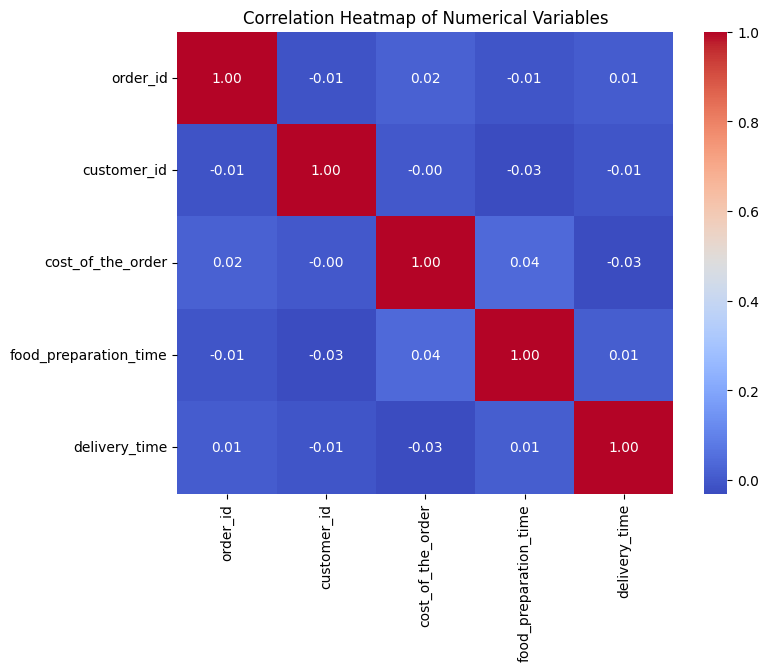

In [ ]:
# Explore relationships between numerical variables using a correlation heatmap
correlation_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

The diagonal line shows a perfect positive correlation (1.00) of each variable with itself, which is expected.
There doesn't appear to be any strong linear correlation between cost_of_the_order, food_preparation_time, and delivery_time. The correlation coefficients between these variables are relatively low, close to zero. This suggests that changes in the cost of the order or food preparation time do not have a strong linear relationship with delivery time.
order_id and customer_id also show very low correlations with the other numerical variables, which is expected as they are unique identifiers and not expected to have a linear relationship with cost or time variables.
In summary, the heatmap indicates that among the numerical variables, there are no strong linear relationships that stand out.

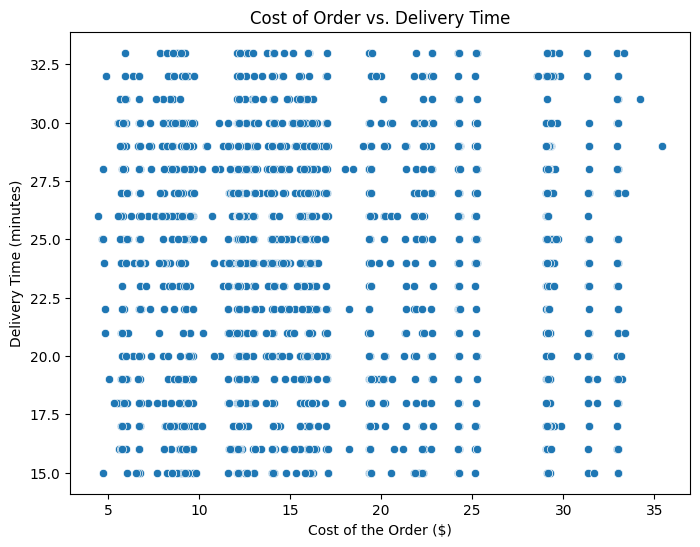

In [ ]:
# Explore relationship between cost of order and delivery time using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='cost_of_the_order', y='delivery_time')
plt.title('Cost of Order vs. Delivery Time')
plt.xlabel('Cost of the Order ($)')
plt.ylabel('Delivery Time (minutes)')
plt.show()

Each point on the plot represents a single order. By looking at the distribution of these points, it appears that there is no strong linear relationship between the cost of the order and the delivery time. The points are scattered without a clear upward or downward trend, suggesting that more expensive orders don't necessarily take significantly longer or shorter to deliver compared to less expensive orders. There might be some clustering of points in certain areas, but overall, a strong linear correlation is not evident from this plot, which aligns with the low correlation coefficient observed in the heatmap earlier.

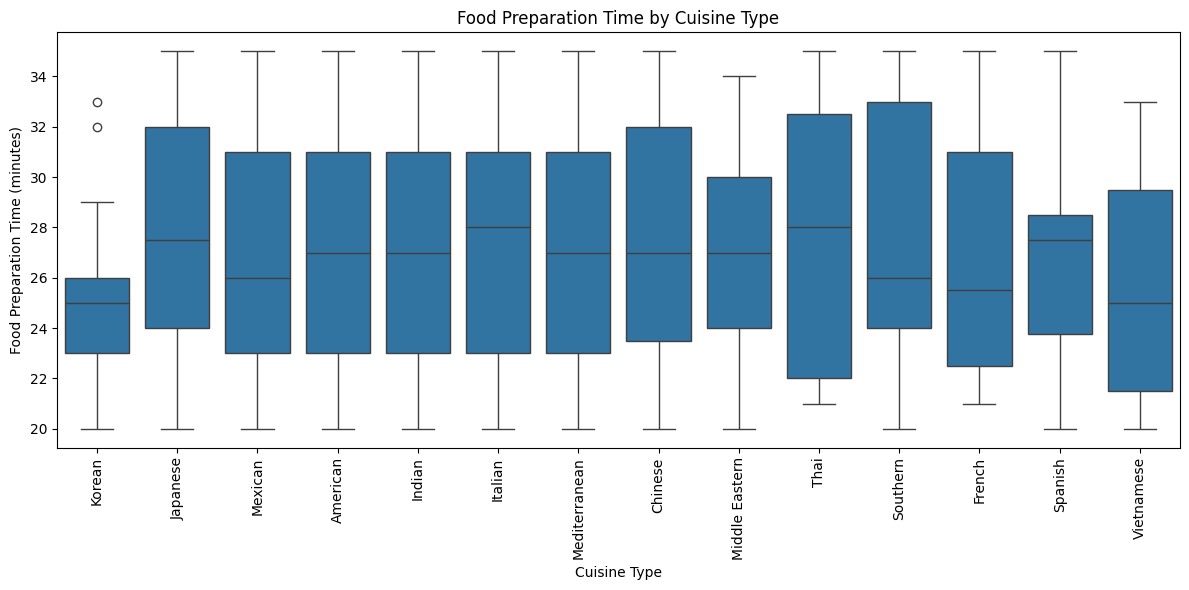

In [ ]:
# Explore relationship between cuisine type and food preparation time using a box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='cuisine_type', y='food_preparation_time')
plt.title('Food Preparation Time by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The median food preparation times appear to be relatively similar across most cuisine types, generally falling between approximately 25 and 30 minutes.
Some cuisine types, like 'American', 'Japanese', and 'Italian', have a larger number of orders as indicated by the count in the earlier analysis, and their boxplots show a consistent range of preparation times.
Cuisine types with fewer orders may show more variability or have outliers, but it's harder to draw strong conclusions for these due to the smaller sample size.
There are some outliers for several cuisine types, indicating orders that had significantly longer or shorter food preparation times than the majority of orders for that cuisine.
Overall, while the median preparation times are similar, there are variations in the range and spread of preparation times across different cuisine types.

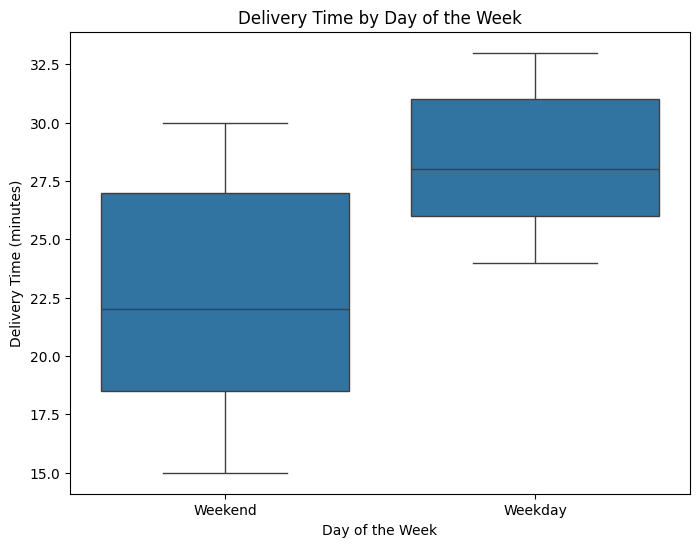

In [ ]:
# Explore relationship between day of the week and delivery time using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.title('Delivery Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.show()

The mean delivery time for Weekday orders is approximately 28.34 minutes.
The mean delivery time for Weekend orders is approximately 22.47 minutes.
This suggests: the average delivery time is longer on weekdays compared to weekends.

In [ ]:
# Write the code here
# 1. Box Plot


# 2. Regression Plot (to vicorrelation_matrix = df.corr()


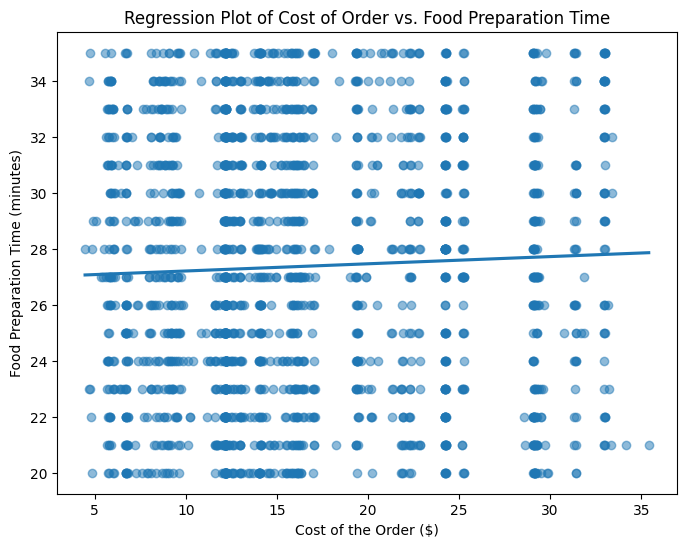

In [ ]:
# Explore relationship between cost of order and food preparation time using a regression plot
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='cost_of_the_order', y='food_preparation_time', ci=None, scatter_kws={'alpha':0.5})
plt.title('Regression Plot of Cost of Order vs. Food Preparation Time')
plt.xlabel('Cost of the Order ($)')
plt.ylabel('Food Preparation Time (minutes)')
plt.show()

###Observation
The regression line is relatively flat, and the data points are scattered quite broadly around it, indicating a weak linear relationship between the cost of an order and how long it takes to prepare.

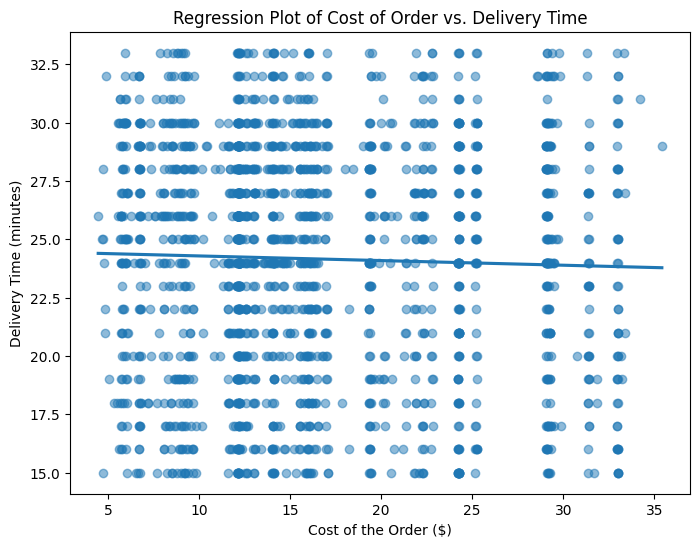

In [ ]:
# Explore relationship between cost of order and delivery time using a regression plot
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='cost_of_the_order', y='delivery_time', ci=None, scatter_kws={'alpha':0.5})
plt.title('Regression Plot of Cost of Order vs. Delivery Time')
plt.xlabel('Cost of the Order ($)')
plt.ylabel('Delivery Time (minutes)')
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer

In [ ]:
# Convert 'rating' column to numeric, coercing errors
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Group by restaurant and calculate the count and mean of ratings
restaurant_ratings = df.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()

# Filter for restaurants with rating count > 50 and average rating > 4
promotional_restaurants = restaurant_ratings[(restaurant_ratings['count'] > 50) & (restaurant_ratings['mean'] > 4)]

# Display the restaurants fulfilling the criteria
print("Restaurants fulfilling the criteria for the promotional offer:")
display(promotional_restaurants)

Restaurants fulfilling the criteria for the promotional offer:


,restaurant_name,count,mean
20,Blue Ribbon Fried Chicken,64,4.328125
21,Blue Ribbon Sushi,73,4.219178
136,Shake Shack,133,4.278195
153,The Meatball Shop,84,4.511905


#### Observations:
There are 4 Restaurant which eligible for the promotional offer and theY are Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders

In [ ]:
# Calculate revenue for orders > $20 (25% commission)
revenue_gt_20 = (df[df['cost_of_the_order'] > 20]['cost_of_the_order'] * 0.25).sum()

# Calculate revenue for orders > $5 and <= $20 (15% commission)
revenue_gt_5_le_20 = (df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'] * 0.15).sum()

# Calculate the net revenue
net_revenue = revenue_gt_20 + revenue_gt_5_le_20

print(f"Net revenue generated by the company: ${net_revenue:.2f}")

Net revenue generated by the company: $6166.30


#### Observations:
Net revenue generated by the company: $6166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered)

In [ ]:
# Calculate the total delivery time (food preparation time + delivery time)
df['total_delivery_time'] = df['food_preparation_time'] + df['delivery_time']

# Count the number of orders that took more than 60 minutes
orders_gt_60_minutes = df[df['total_delivery_time'] > 60].shape[0]

# Calculate the percentage of orders that took more than 60 minutes
percentage_gt_60_minutes = (orders_gt_60_minutes / len(df)) * 100

print(f"Percentage of orders taking more than 60 minutes to be delivered: {percentage_gt_60_minutes:.2f}%")

Percentage of orders taking more than 60 minutes to be delivered: 10.54%


#### Observations:
Percentage of orders taking more than 60 minutes to be delivered: 10.54%

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [ ]:
# Calculate the mean delivery time for weekdays and weekends
mean_delivery_time_by_day = df.groupby('day_of_the_week')['delivery_time'].mean()

print("Mean delivery time by day of the week:")
display(mean_delivery_time_by_day)

Mean delivery time by day of the week:


,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
It is observed that the mean delivery time during weekdays is more then compare to weekend .So it is seen that it usually take longer to deliver during the weekdays the during weekends

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations)

### Conclusions:

Based on the analysis, we can draw the following conclusions:

*   **Data Overview:** The dataset contains information on customer orders, including restaurant details, cuisine types, costs, delivery times, and ratings. There are no missing values.
*   **Food Preparation and Delivery Time:** The average food preparation time is around 27 minutes, and the average delivery time is about 24 minutes. A significant percentage of orders (around 10.54%) take longer than 60 minutes in total (preparation + delivery).
*   **Popular Restaurants and Cuisines:** Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm are the top 5 restaurants by number of orders. American cuisine is the most popular on weekends.
*   **Order Cost:** Approximately 29.24% of orders cost more than 20 dollars.
*   **Customer Loyalty:** The top 3 most frequent customers have placed a considerable number of orders, indicating potential for loyalty programs.
*   **Revenue:** The company generates revenue through commissions on orders, with higher commissions for orders over $20.
*   **Delivery Time Variation:** Mean delivery time is higher on weekdays compared to weekends.
*   **Restaurant Performance:** Several restaurants meet the criteria for a promotional offer based on rating count and average rating.

### Recommendations:

Here are some recommendations to help improve the business:

*   **Optimize Delivery Routes:** Investigate the reasons for longer delivery times, especially on weekdays, and explore ways to optimize delivery routes and logistics to reduce delivery time and improve customer satisfaction.
*   **Address Unrated Orders:** A significant number of orders are not rated. Implement strategies to encourage customers to provide ratings, such as push notifications or small incentives, to gather more feedback and improve service quality.
*   **Promotional Offers:** Utilize the list of restaurants that meet the criteria for the promotional offer. Collaborate with these restaurants to create targeted advertising campaigns and special deals to attract more customers to them.
*   **Customer Loyalty Program:** Implement a tiered loyalty program for frequent customers, offering exclusive discounts or perks to the top customers to encourage repeat business.
*   **Analyze Cuisine Performance:** Further analyze the performance of different cuisine types, including preparation times and customer ratings, to identify areas for improvement or expansion.
*   **Investigate High-Cost Orders:** Understand the characteristics of orders with costs greater than $20. This could involve analyzing the types of restaurants, cuisines, or customer segments associated with these orders to identify opportunities for upselling or targeted marketing.
*   **Gather Feedback on Delivery Time:** For orders exceeding 60 minutes, consider implementing a system to gather specific feedback from customers to understand the root causes of delays and address them proactively.

---